# Extended IBTrACS visualisation examples

In [22]:
# Setup environment
import huracanpy
import numpy as np
import xarray as xr
from shapely import Polygon, Point
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import seaborn as sns

In [60]:
# Script parameters
IN_FILE = "../files/extended_ibtracs_distaz.nc"
PROJ = ccrs.AlbersEqualArea(central_longitude=-45, central_latitude=33,)

In [61]:
# Open extended IBTrACS
eib = xr.open_dataset(IN_FILE)

## Plot different tracks for a given storm

In [25]:
palette = {
    "IBTrACS" : "k",
    "TRACK-ERA5": sns.color_palette("colorblind")[1],
    "SyCLoPS-ERA5": sns.color_palette("colorblind")[3],
    "TRACK-JRA3Q": sns.color_palette("colorblind")[0],
    "TRACK-ERA20C": sns.color_palette("colorblind")[2],
    "TRACK-ECMWF-OP-AN": sns.color_palette("colorblind")[5],
}

In [71]:
def plot_composite(tracks, id_ib):
    track = tracks.hrcn.sel_id(id_ib) # Subset specific track
    name = track.name[0].values # Identify name

    # Create plot
    fig, axs = plt.subplots(1,1, subplot_kw = dict(projection = PROJ), figsize = [8,8])
    axs.coastlines()
    for ds in track.dataset.values:
        # Subset track for one dataset
        track_ds = track.sel(dataset = ds)
        if (~np.isnan(track_ds.lon)).sum() > 0: # If track exists for this dataset
            # remove NaNs (for continuous plotting)
            track_ds = track_ds.where(~np.isnan(track_ds.lon), drop = True)
            # Draw track
            axs.plot(track_ds.lon, track_ds.lat, marker = '.', label = ds, color = palette[ds], 
                     transform = ccrs.PlateCarree())

    # Layout
    plt.legend()
    plt.title(name + ' ('+id_ib+')')

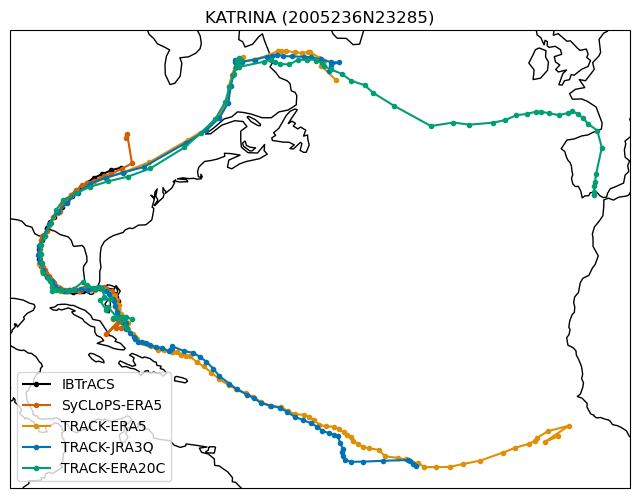

In [72]:
plot_composite(eib, "2005236N23285") 

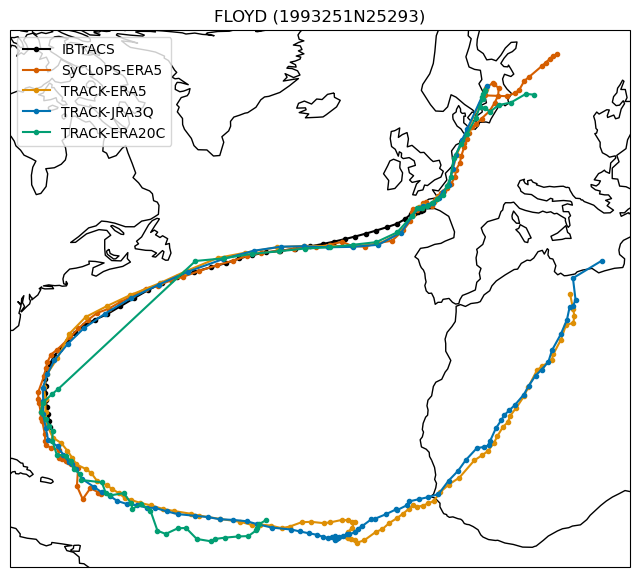

In [73]:
plot_composite(eib, "1993251N25293") 

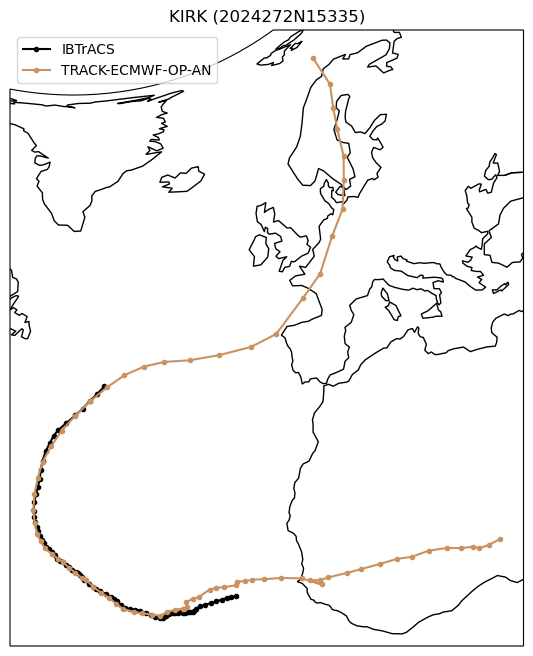

In [74]:
plot_composite(eib, "2024272N15335")

## Time series

In [64]:
track = eib.where((eib.name == "track") & (eib.time.dt.year == 1995), drop = True)
track = track.set_coords("time")
track_ib = track.sel(dataset="IBTrACS").where(~np.isnan(track.sel(dataset="IBTrACS").lon), drop = True)

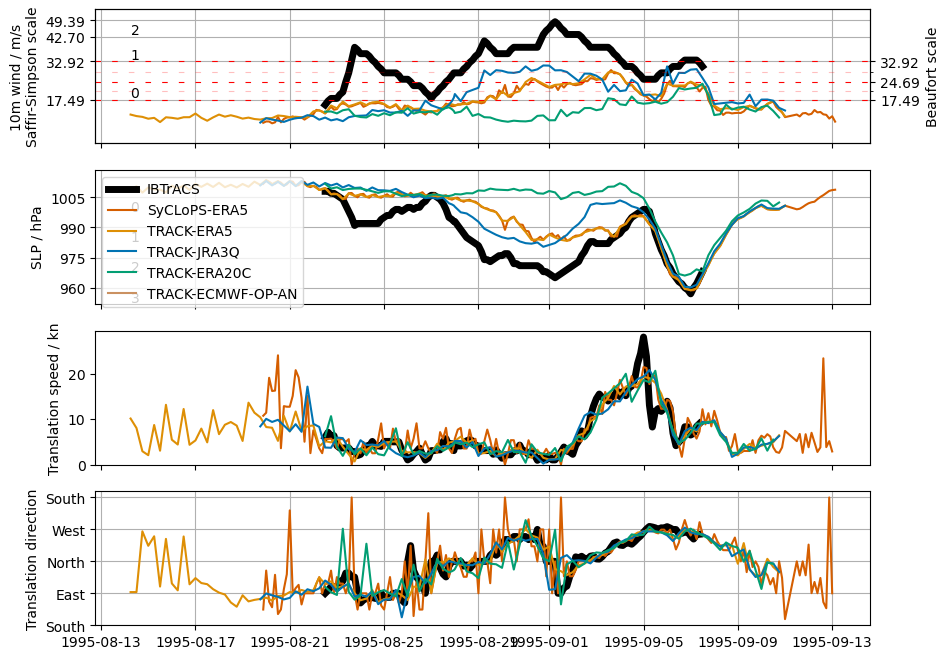

In [70]:
N = 4 # Number of lines
saffir_simpson = np.array([34., 64., 83., 96., 113., 136.]) * 0.514444
Beaufort = np.array([34,41,48,56,64]) * 0.514444

# Setup plot
fig, axs = plt.subplots(N, figsize = (10,N*2), sharex = True)

# Plot data
for ds in track.dataset.values:
    K = track.sel(dataset = ds).squeeze()
    color = 'k' if ds == 'IBTrACS' else None
    lw = 5 if ds == 'IBTrACS' else None
    axs[0].plot(K.time, K.wind10.interpolate_na("record"), color = palette[ds], lw = lw, label = ds)
    axs[1].plot(K.time, K.pres.interpolate_na("record"), color = palette[ds], lw = lw, label = ds)
    axs[2].plot(K.time, K.translation_speed.interpolate_na("record"), color = palette[ds], lw = lw, label = ds)
    axs[3].plot(K.time, K.azimuth.interpolate_na("record"), color = palette[ds], lw = lw, label = ds)
    
# Layout
## Wind panel
axs[0].set_ylabel("10m wind / m/s\nSaffir-Simpson scale")
axs[0].grid()
axs[0].set_yticks(saffir_simpson) # On the left, have SSHS scale
for cat in range(5,-1,-1): # Write SSHS category labels
    thresh = saffir_simpson[cat]
    if track.wind10.max() > thresh:
        axs[0].text(x = track.time.min(skipna = True), y = thresh + 1, s = cat)
axs[0].set_ylim(0, track.wind10.max()+5) # Reduce y-axis to the track data
ax_wind_Beauf = axs[0].twinx() # Create right axis for Beaufort scale
ax_wind_Beauf.set_yticks(Beaufort[::2],) # Set Beaufort right y-ticks
ax_wind_Beauf.set_yticks(Beaufort, minor = True) # Set Beaufort right y-ticks
ax_wind_Beauf.set_ylim(0, track.wind10.max()+5) # Set same limits as the left to make sure they align
ax_wind_Beauf.grid(color = 'red', linestyle = (0, (5, 10)))
ax_wind_Beauf.grid(color = 'red', which = "minor", linestyle = (0, (5, 10)), alpha = 0.25)
ax_wind_Beauf.set_ylabel("Beaufort scale")

## SLP panel
axs[1].set_ylabel("SLP / hPa")
axs[1].set_yticks(huracanpy.tc._conventions._thresholds["Klotzbach"]["bins"].magnitude[1:-1])
axs[1].grid()
for i, cat in enumerate(range(5,-1,-1)):
    thresh = huracanpy.tc._conventions._thresholds["Klotzbach"]["bins"].magnitude[1:-1][i]
    if track.pres.min() < thresh:
        axs[1].text(x = track.time.min(skipna = True), y = thresh-7, s = cat)
axs[1].set_ylim(track.pres.min()-5, track.pres.max()+5,)
axs[1].legend()

# Translation speed panel
axs[2].set_ylabel("Translation speed / kn")
axs[2].set_ylim(0)

# Direction panel 
axs[3].set_ylabel("Translation direction",)
axs[3].set_yticks(ticks = np.arange(-180,180.1,90), labels = ["South", "East", "North", "West", "South"],)
axs[3].grid()

# Plot important times
for ax in axs:
    ax.grid(axis = 'x', which = "minor", color = "k")

## Visualise phase space

In [79]:
IN_FILE = "../files/extended_ibtracs_CPS.nc"
eib = xr.open_dataset(IN_FILE)
track = eib.where((eib.name == "IRENE") & (eib.time.dt.year == 1981), drop = True)

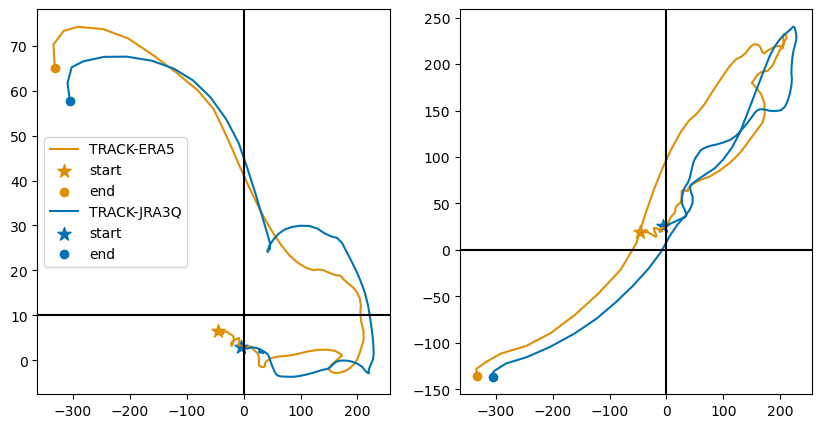

In [96]:
fig, axs = plt.subplots(1, 2, figsize = (10,5))

for ds in track.dataset.values:
    K = track.sel(dataset = ds).squeeze()
    K_smooth = K[["Vtu", "Vtl", "B"]].interpolate_na("record").rolling(record = 8*1, center = True).mean()
    K_smooth = K_smooth.where(~np.isnan(K_smooth.B), drop = True)
    if len(K_smooth.record) > 0:
        axs[0].plot(K_smooth.Vtl, K_smooth.B, color = palette[ds], label = ds)
        axs[1].plot(K_smooth.Vtl, K_smooth.Vtu, color = palette[ds], label = ds)
        axs[0].scatter(K_smooth.isel(record = 0).Vtl, K_smooth.isel(record = 0).B, color = palette[ds], marker = '*', s=100, label = "start")
        axs[1].scatter(K_smooth.isel(record = 0).Vtl, K_smooth.isel(record = 0).Vtu, color = palette[ds], marker = '*', s=100, label = "start")
        axs[0].scatter(K_smooth.isel(record = -1).Vtl, K_smooth.isel(record = -1).B, color = palette[ds], marker = 'o', label = "end")
        axs[1].scatter(K_smooth.isel(record = -1).Vtl, K_smooth.isel(record = -1).Vtu, color = palette[ds], marker = 'o', label = "end")
           
axs[0].axhline(y = 10, color = 'k')
axs[0].axvline(x = 0, color = 'k')
axs[1].axhline(y = 0, color = 'k')
axs[1].axvline(x = 0, color = 'k')
axs[0].legend()